Shape of the DataFrame: (200, 6)

Data Types:
order_id           int64
city                 str
category             str
order_value      float64
delivery_days    float64
rating            object
dtype: object

Missing Values Count:
order_id          0
city              0
category          0
order_value      14
delivery_days    10
rating           32
dtype: int64

Percentage of Missing Values:
order_id          0.0
city              0.0
category          0.0
order_value       7.0
delivery_days     5.0
rating           16.0
dtype: float64
          order_id   order_value  delivery_days
count   200.000000    186.000000     190.000000
mean   1100.500000   3707.134409       7.810526
std      57.879185   9238.438378       4.075465
min    1001.000000    204.000000       1.000000
25%    1050.750000   1512.000000       4.000000
50%    1100.500000   2934.000000       8.000000
75%    1150.250000   3987.500000      12.000000
max    1200.000000  95000.000000      14.000000


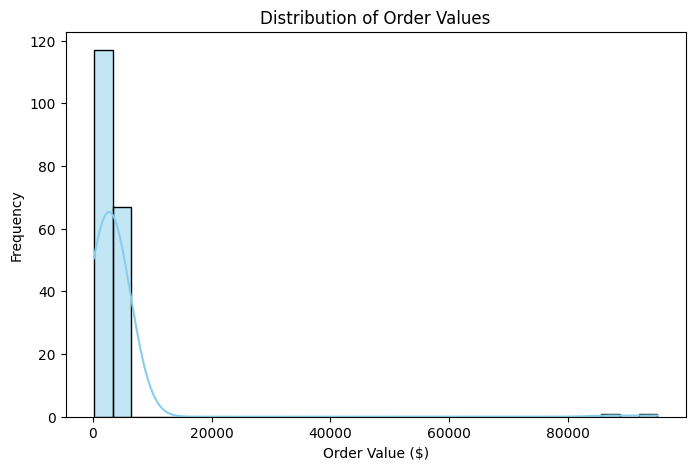

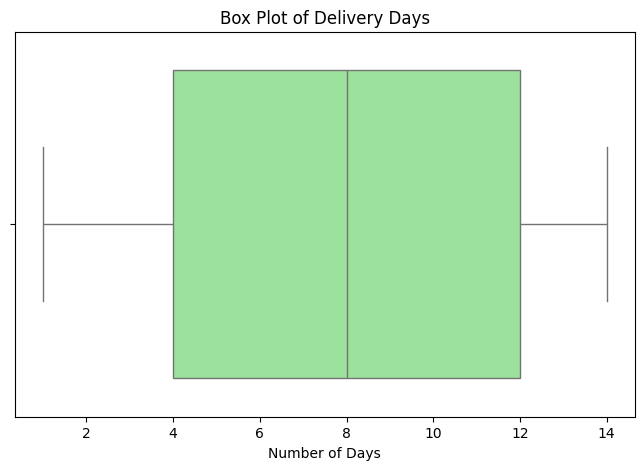

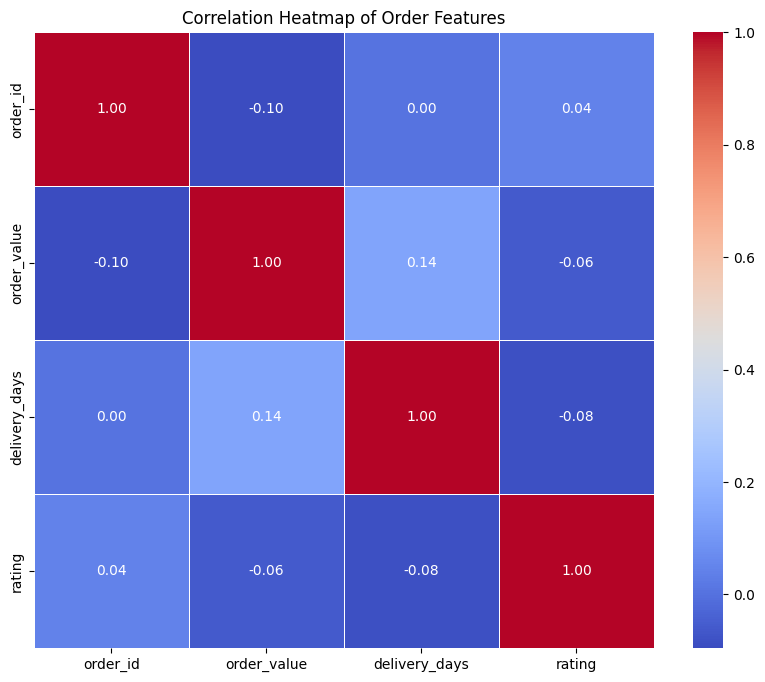

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)
df.head()

# 1. Print the shape of the DataFrame
print("Shape of the DataFrame:", df.shape)

# 2. Display the data types of all columns
print("\nData Types:")
print(df.dtypes)

# 3. Count the number of missing values in each column
missing_counts = df.isnull().sum()
print("\nMissing Values Count:")
print(missing_counts)

# 4. Calculate the percentage of missing values
total_rows = len(df)
missing_percentage = (missing_counts / total_rows) * 100
print("\nPercentage of Missing Values:")
print(missing_percentage.round(2))


import matplotlib.pyplot as plt
import seaborn as sns

# 1. Summary of numerical columns
summary = df.describe()
print(summary)

# 2. Histogram for order_value
plt.figure(figsize=(8, 5))
sns.histplot(df['order_value'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribution of Order Values')
plt.xlabel('Order Value ($)')
plt.ylabel('Frequency')
plt.show()

# 3. Box plot for delivery_days
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['delivery_days'], color='lightgreen')
plt.title('Box Plot of Delivery Days')
plt.xlabel('Number of Days')

plt.show()


import seaborn as sns
import matplotlib.pyplot as plt

# 1. Compute the correlation matrix for numerical columns
# Note: rating needs to be treated as a number
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# 2. Plot a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Order Features')
plt.show()